## Imports and Configuration

In [26]:
%matplotlib inline
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

## Data Loading and Preprocessing

In [27]:
print("Loading data...")
data = scipy.io.loadmat('datasets/bean_data.mat') 
X_raw = data['feat']

# --- FIX: ROBUST LABEL CLEANING ---
# .mat files often load strings as nested arrays. This extracts the actual text.
# We iterate through the raw labels and grab the string inside.
y_raw_dirty = data['lbl']
y_raw = np.array([str(x[0]) if isinstance(x, (np.ndarray, list)) else str(x) for x in y_raw_dirty])

# Remove any accidental whitespace
y_raw = np.char.strip(y_raw)

# define standard feature names
feature_names = [
    'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 
    'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 
    'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4'
]

# Create DataFrame
df = pd.DataFrame(X_raw, columns=feature_names)
df['Class_Name'] = y_raw 

# Standardize for ML
le = LabelEncoder()
y = le.fit_transform(y_raw) 
# Dynamically get class names to ensure they match the data exactly
class_names = list(le.classes_) 

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=feature_names)

print(f"Data Loaded and Cleaned.")
print(f"Classes found: {class_names}")

Loading data...
Data Loaded and Cleaned.
Classes found: [np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7')]


## Data Visualization

### Class Distribution  
This checks if your data is balanced.

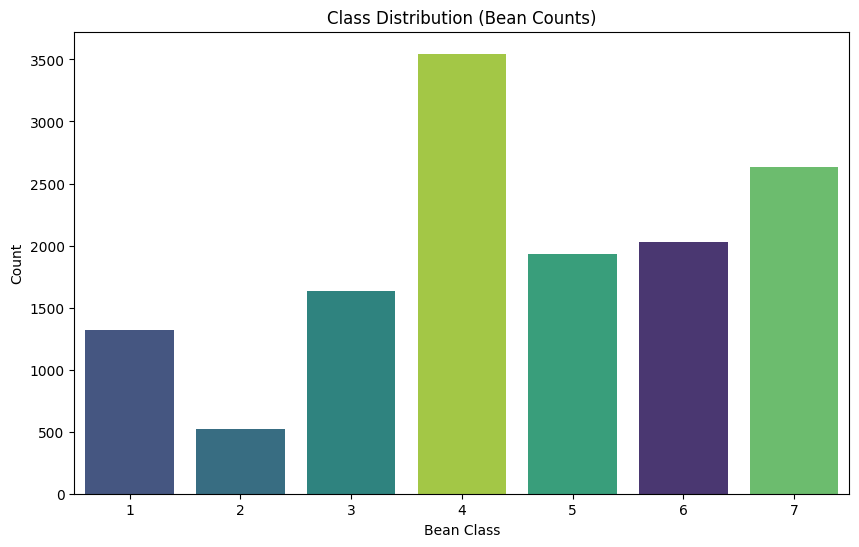

In [28]:
# --- VISUALIZATION PART 1: CLASS BALANCE ---
plt.figure(figsize=(10, 6))

# Using the class_names we detected in the loading step ensures the order is correct
sns.countplot(x='Class_Name', data=df, hue='Class_Name', palette='viridis', legend=False, order=class_names)

plt.title('Class Distribution (Bean Counts)')
plt.xlabel('Bean Class')
plt.ylabel('Count')
plt.show()

### Feature Correlation Matrix  
This helps you see which features provide unique info and which are redundant (high correlation).

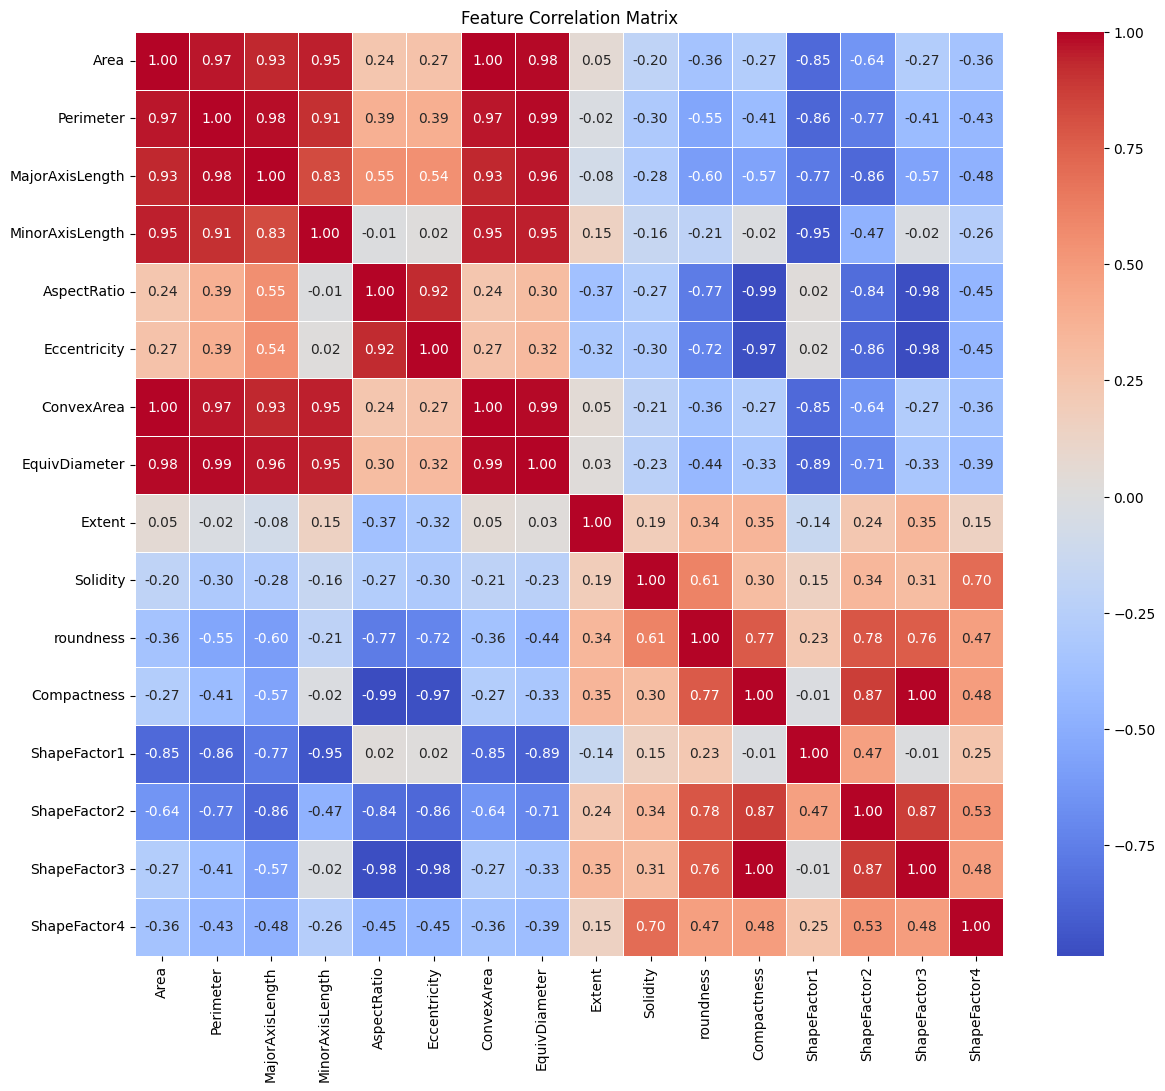

In [29]:
# --- VISUALIZATION PART 2: CORRELATION MATRIX ---
# We drop the string column 'Class_Name' to calculate correlations only on numbers
numeric_df = df.drop(columns=['Class_Name']) 

plt.figure(figsize=(14, 12))
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

### Feature Histograms

This shows the "shape" of your data (e.g., bell curves).

Displaying Feature Distributions...


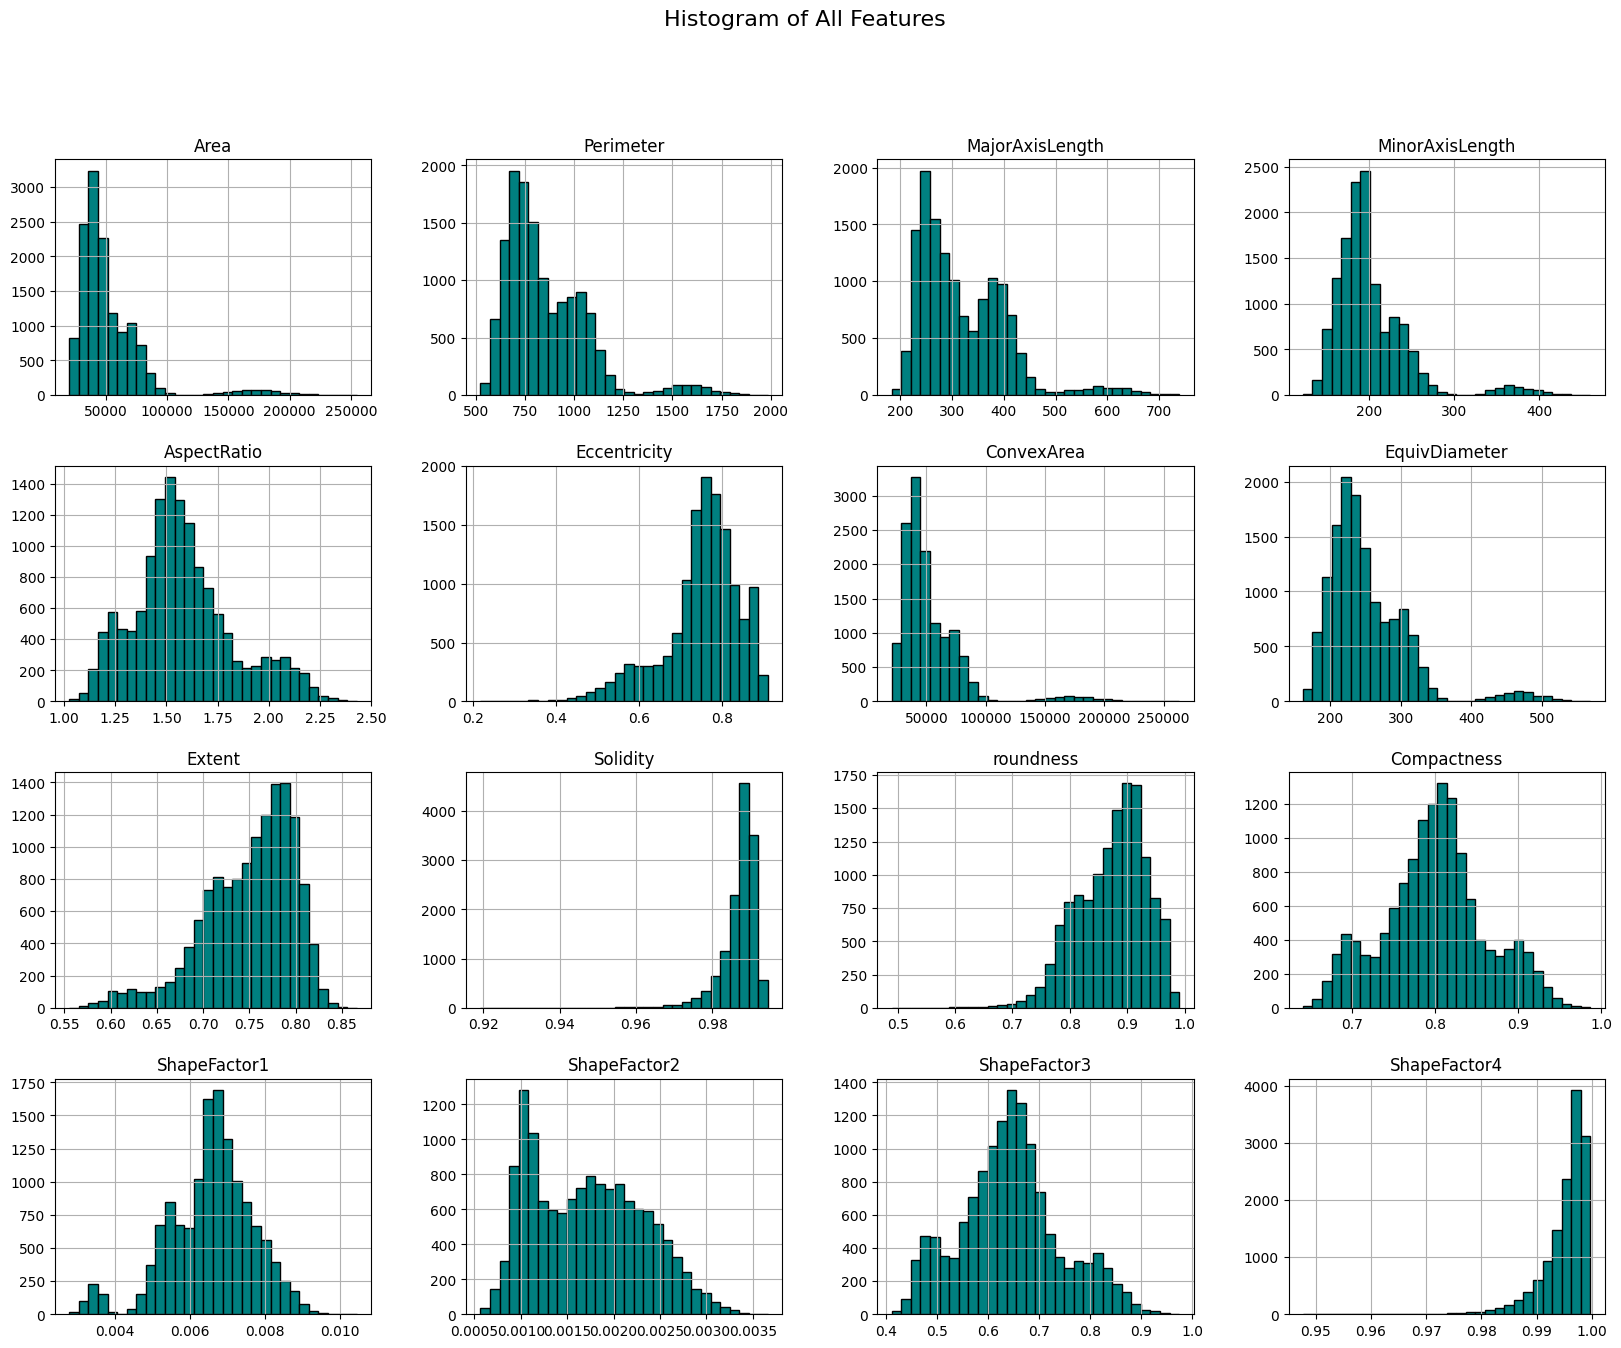

In [30]:
# --- VISUALIZATION PART 3: HISTOGRAMS ---
print("Displaying Feature Distributions...")

# We drop 'Class_Name' to ensure we only have the 16 numeric features
# This fits perfectly into the 4x4 layout
df.drop(columns=['Class_Name']).hist(bins=30, figsize=(20, 15), layout=(4, 4), color='teal', edgecolor='black')

plt.suptitle('Histogram of All Features', fontsize=16)
plt.show()

## Model Definitions

In [31]:
# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Define Dictionary of Models
models = {
    # --- MODEL 1: The Classic (Geometric) ---
    "SVM": SVC(probability=True), 
    
    # --- MODEL 2: The Modern Standard (Ensemble) ---
    "CatBoost": cb.CatBoostClassifier(verbose=0, random_state=42),

    # --- OTHERS (Commented out) ---
    # "KNN": KNeighborsClassifier(),
    # "ANN": MLPClassifier(max_iter=500, random_state=42),
    # "NaiveBayes": GaussianNB(),
    # "XGBoost": xgb.XGBClassifier(verbosity=0, random_state=42),
    # "LightGBM": lgb.LGBMClassifier(verbose=-1, random_state=42),
}

print(f"Selected Models: {list(models.keys())}")

Selected Models: ['SVM', 'CatBoost']


## Training Loop

==================== TRAINING STARTED ====================
-> Processing SVM...
-> Processing CatBoost...

==================== PLOTTING RESULTS ====================


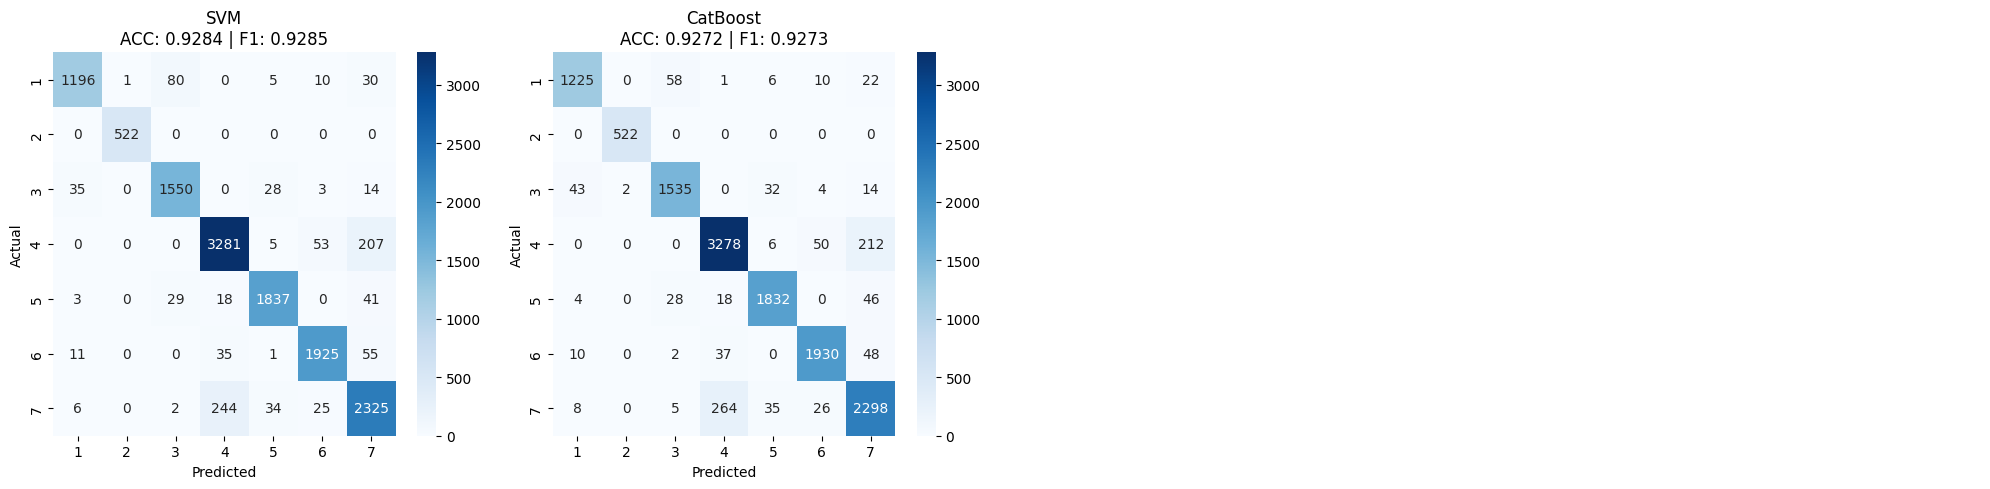

In [32]:
from sklearn.metrics import classification_report

# Initialize storage for detailed results
results = []
per_class_results = [] # New list to store score per bean type
stored_cms = [] 

print(f"{'='*20} TRAINING STARTED {'='*20}")

for name, model in models.items():
    print(f"-> Processing {name}...")
    y_true_all = []
    y_pred_all = []
    
    # Stratified K-Fold
    for train_index, test_index in skf.split(X_scaled, y):
        X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        model.fit(X_train, y_train)
        y_p = model.predict(X_test)
        
        y_true_all.extend(y_test)
        y_pred_all.extend(np.array(y_p).flatten())

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    # 1. Overall Metrics
    acc = accuracy_score(y_true_all, y_pred_all)
    f_score = f1_score(y_true_all, y_pred_all, average='weighted')
    results.append({"Model": name, "ACC": acc, "F-Score": f_score})
    
    # 2. Per-Class Metrics (The new part!)
    report = classification_report(y_true_all, y_pred_all, target_names=class_names, output_dict=True)
    
    for class_name in class_names:
        per_class_results.append({
            "Model": name,
            "Class": class_name,
            "F1-Score": report[class_name]['f1-score']
        })

    # 3. Store Confusion Matrix
    cm = confusion_matrix(y_true_all, y_pred_all)
    stored_cms.append((name, cm, acc, f_score))

print("Training Complete.")

## Final Comparison


   CLASSIFICATION PERFORMANCE RESULTS
   Model      ACC  F-Score
     SVM 0.928367 0.928459
CatBoost 0.927191 0.927250


<Figure size 1200x600 with 0 Axes>

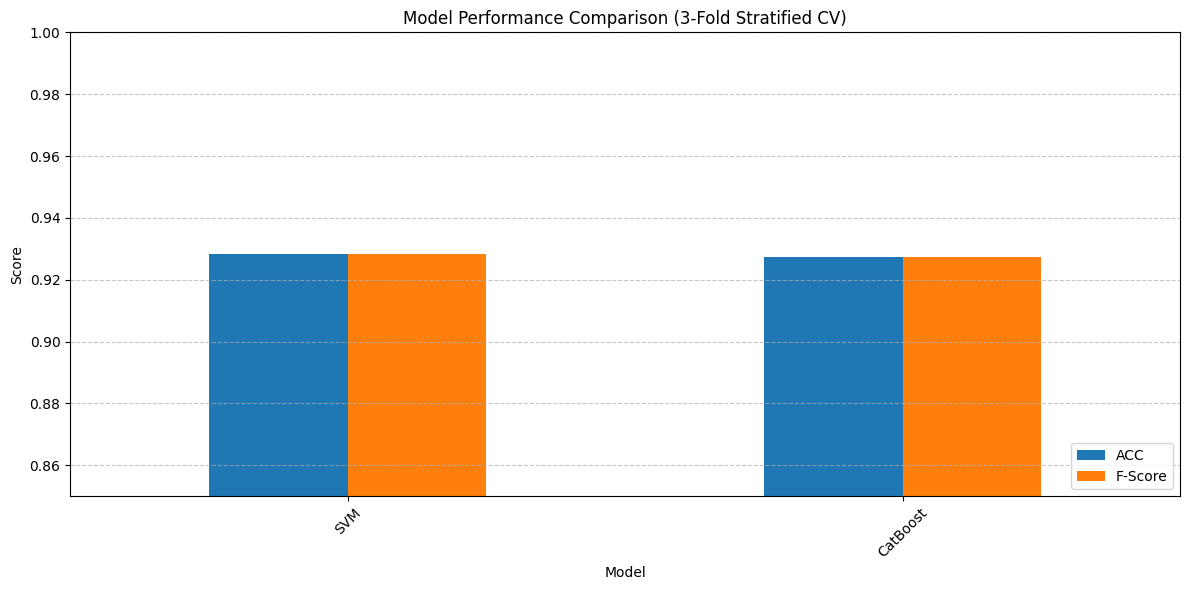

In [33]:
# --- 1. DISPLAY OVERALL RESULTS ---
df_results = pd.DataFrame(results).sort_values(by="ACC", ascending=False)
print("\n" + "="*40)
print("   OVERALL PERFORMANCE")
print("="*40)
print(df_results.to_string(index=False))

# --- 2. PLOT: CLASS-WISE COMPARISON (THE BEST GRAPH) ---
df_per_class = pd.DataFrame(per_class_results)

plt.figure(figsize=(14, 6))
# This creates the side-by-side bars for every bean class
sns.barplot(data=df_per_class, x='Class', y='F1-Score', hue='Model', palette='viridis')

plt.title('Detailed Performance Comparison by Bean Class', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0.8, 1.0) # Zoom in to see the small differences
plt.legend(title='Model', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# --- 3. PLOT: CONFUSION MATRICES (SIDE-BY-SIDE) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, cm, acc, f_score) in enumerate(stored_cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{name}\nACC: {acc:.4f}', fontsize=12)
    axes[i].set_ylabel('Actual Class')
    axes[i].set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()